In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcolors



In [2]:
# US
run_metrics = ['camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CAMELS
               "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
            #    'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS
               'chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS_v3
               'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP
            #    'mswep_precipitation_chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP + CHIRPS
               'mswep_precipitation_chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP + CHIRPS_v3
               ] 

In [3]:
# metrics = pd.read_csv(f"../ensemble_metrics/{run_metrics[0]}.csv")
# metrics.head()


/tmp/ipykernel_38911/3735950618.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(nse_data, labels=labels, showfliers=True)


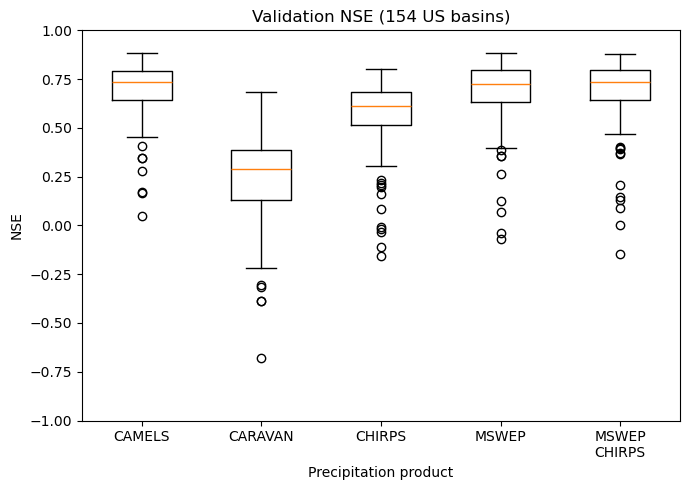

In [5]:
labels = [
    "CAMELS",
    "CARAVAN",
    "CHIRPS",
    # "CHIRPS_v3",
    "MSWEP",
    "MSWEP\nCHIRPS",
    # "MSWEP\nCHIRPS_v3"
]

nse_data = []

for run in run_metrics:
    df = pd.read_csv(f"../ensemble_metrics/{run}.csv")
    nse_data.append(df["NSE"].dropna().values)

plt.figure(figsize=(7, 5))
plt.boxplot(nse_data, labels=labels, showfliers=True)

plt.ylabel("NSE")
plt.xlabel("Precipitation product")
plt.title("Validation NSE (154 US basins)")
plt.ylim(-1,1)  # NSE is typically ≤ 1
plt.tight_layout()
plt.show()

In [9]:
dataset_labels = [
    "CAMELS",
    "CARAVAN",
    "CHIRPS",
    # "CHIRPS_v3",
    "MSWEP",
    "MSWEP\nCHIRPS"
]

metrics_to_plot = ['FHV', 'FMS', 'FLV']

# --- load all data ---
all_metrics = {m: [] for m in metrics_to_plot}

for run in run_metrics:
    df = pd.read_csv(f"../ensemble_metrics/{run}.csv")

    for m in metrics_to_plot:
        all_metrics[m].append(df[m].values)

/tmp/ipykernel_38911/767905962.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')
/tmp/ipykernel_38911/767905962.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')
/tmp/ipykernel_38911/767905962.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')


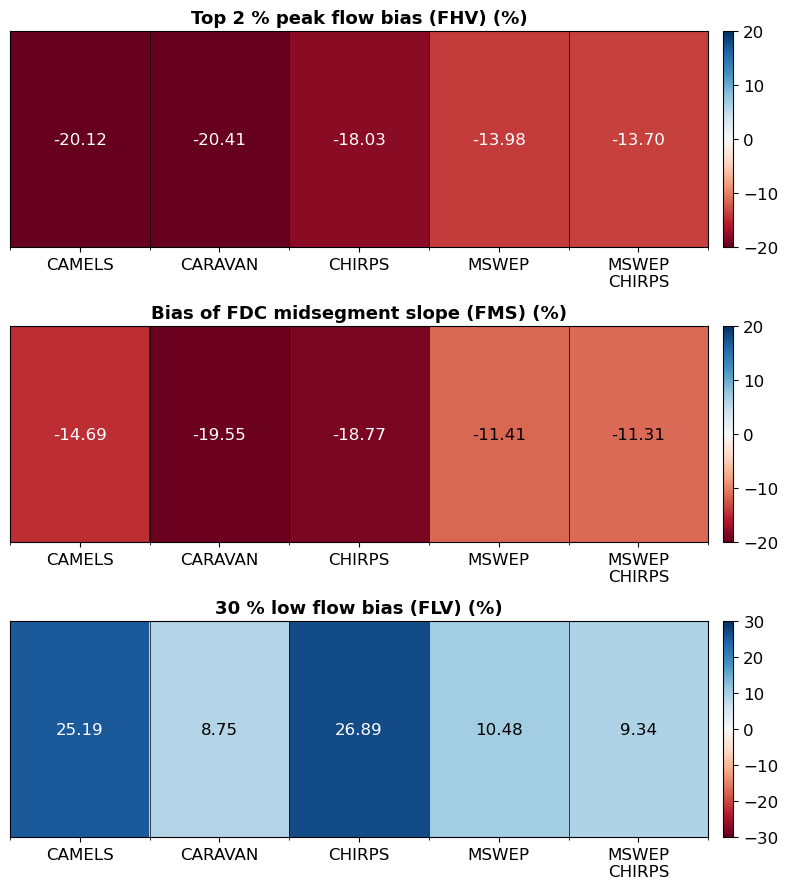

In [19]:
metric_limits = {
    'FHV': (-20, 20),
    'FMS': (-20, 20),
    'FLV': (-30, 30),
}

metric_title = {
    'FHV': 'Top 2 % peak flow bias (FHV) (%)',
    'FMS': 'Bias of FDC midsegment slope (FMS) (%)',
    'FLV': '30 % low flow bias (FLV) (%)',
}

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 9))

for ax, metric in zip(axes, metrics_to_plot):

    # median per dataset
    medians = np.array([np.nanmedian(values) for values in all_metrics[metric]])
    data_2d = medians.reshape(1, -1)

    vmin, vmax = metric_limits[metric]
    cmap = mcm.get_cmap('RdBu')
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax.imshow(data_2d, aspect='auto', cmap=cmap, norm=norm)

    ax.set_xlim(-0.5, len(medians) - 0.5)

    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=12)

    for j, val in enumerate(medians):
        rgba = cmap(norm(val))
        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = 'black' if brightness > 0.5 else 'white'

        ax.text(
            j, 0,
            f"{val:.2f}",
            ha='center',
            va='center',
            fontsize=12,
            color=text_color
        )

    ax.set_title(metric_title[metric], fontsize=13, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks(range(len(dataset_labels)))
    ax.set_xticklabels(dataset_labels, fontsize=12)
    ax.set_xticks(np.arange(-0.5, len(medians), 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [21]:
metrics_to_plot = ['Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

all_metrics = {m: [] for m in metrics_to_plot}

for run in run_metrics:
    df = pd.read_csv(f"../ensemble_metrics/{run}.csv")

    for m in metrics_to_plot:
        all_metrics[m].append(df[m].values)

/tmp/ipykernel_38911/1342423455.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')
/tmp/ipykernel_38911/1342423455.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')
/tmp/ipykernel_38911/1342423455.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')


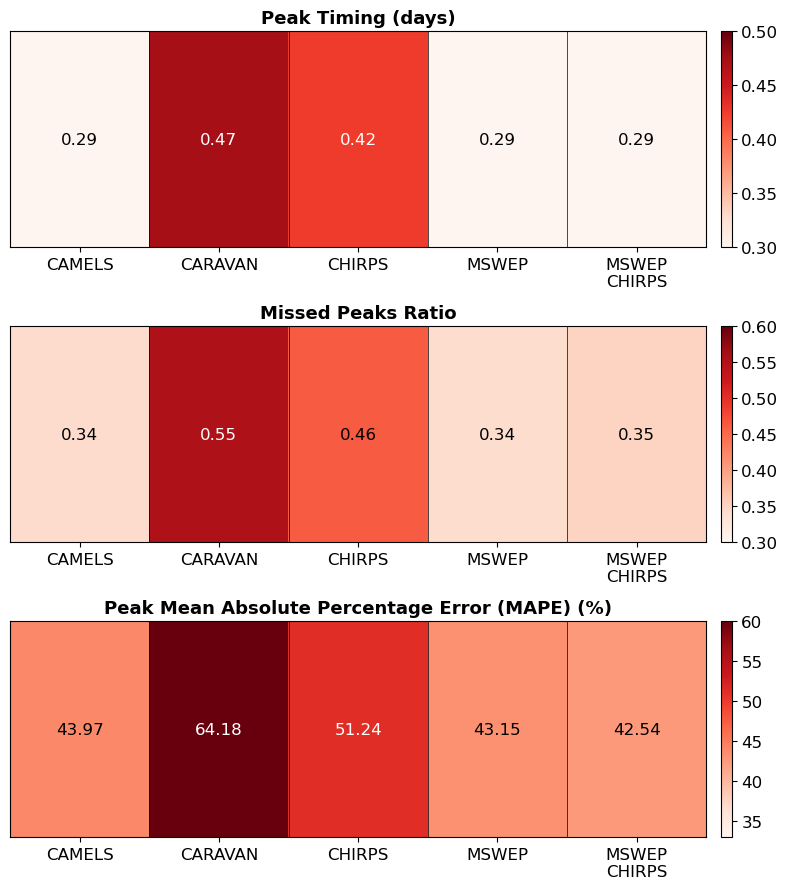

In [29]:
metric_limits = {
    'Peak-Timing':  (0.3, 0.5),
    'Missed-Peaks': (0.3, 0.6),
    'Peak-MAPE':    (33,   60),
}

metric_title = {
    'Peak-Timing':  'Peak Timing (days)',
    'Missed-Peaks': 'Missed Peaks Ratio',
    'Peak-MAPE':    'Peak Mean Absolute Percentage Error (MAPE) (%)',
}

fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 9))

for ax, metric in zip(axes, metrics_to_plot):

    # median per dataset (same structure as before)
    medians = np.array([np.nanmedian(values) for values in all_metrics[metric]])
    data_2d = medians.reshape(1, -1)

    vmin, vmax = metric_limits[metric]

    cmap = mcm.get_cmap('Reds')
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    im = ax.imshow(data_2d, aspect='auto', cmap=cmap, norm=norm)
    
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-0.5, len(medians) - 0.5)

    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=12)

    for j, val in enumerate(medians):
        rgba = cmap(norm(val))
        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = 'black' if brightness > 0.5 else 'white'

        ax.text(
            j, 0,
            f"{val:.2f}",
            ha='center',
            va='center',
            fontsize=12,
            color=text_color
        )

    ax.set_title(metric_title[metric], fontsize=13, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks(range(len(dataset_labels)))
    ax.set_xticklabels(dataset_labels, fontsize=12)

    for j in range(len(medians) - 1):
        ax.axvline(j + 0.5, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()